# LSTM Model Comparison

Финальное сравнение one-step LSTM, базовой many-to-many LSTM и архитектурных вариантов many-to-many.

Все модели сравниваются по одной схеме:

```text
score = nll_max = max(-log P(true_next_event)) по block_id

threshold подбирается на validation по максимуму F1

итоговые метрики считаются на test
```

### Импорты

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

cwd = Path.cwd().resolve()
if (cwd / "FastAPI").exists():
    CHECKPOINT_DIR = cwd
elif cwd.name == "notebooks" and (cwd.parent / "FastAPI").exists():
    CHECKPOINT_DIR = cwd.parent
else:
    CHECKPOINT_DIR = cwd / "Checkpoint_6"

sys.path.insert(0, str(CHECKPOINT_DIR / "FastAPI"))

from model.lstm_model import LSTMNextEventModel
from model.lstm_token_model import LSTMNextTokenModel

plt.style.use("default")
EVAL_DEVICE = "cpu"

### Загрузка данных

In [2]:
ONE_STEP_DATA_PATH = CHECKPOINT_DIR / "data" / "preprocessed" / "seq_out" / "hdfs_sequence_data.npz"
TOKEN_DATA_PATH = CHECKPOINT_DIR / "data" / "preprocessed" / "token_seq_out" / "hdfs_token_sequence_data.npz"

for path in [ONE_STEP_DATA_PATH, TOKEN_DATA_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

one_data = np.load(ONE_STEP_DATA_PATH, allow_pickle=True)
token_data = np.load(TOKEN_DATA_PATH, allow_pickle=True)

one = {
    "x_val": one_data["X_val"],
    "y_val": one_data["y_val"],
    "x_test": one_data["X_test"],
    "y_test": one_data["y_test"],
    "val_labels": one_data["val_labels"].astype(int),
    "test_labels": one_data["test_labels"].astype(int),
    "val_block_ids": one_data["val_block_ids"].astype(str),
    "test_block_ids": one_data["test_block_ids"].astype(str),
}

token = {
    "x_val": token_data["X_val"],
    "y_val": token_data["Y_val"],
    "x_test": token_data["X_test"],
    "y_test": token_data["Y_test"],
    "val_labels": token_data["val_labels"].astype(int),
    "test_labels": token_data["test_labels"].astype(int),
    "val_block_ids": token_data["val_block_ids"].astype(str),
    "test_block_ids": token_data["test_block_ids"].astype(str),
}

print("one-step val/test:", one["x_val"].shape, one["x_test"].shape)
print("many-to-many val/test:", token["x_val"].shape, token["x_test"].shape)
print("test anomaly share by blocks:")
for name, ds in [("one-step", one), ("many-to-many", token)]:
    block_label = {}
    for bid, lbl in zip(ds["test_block_ids"], ds["test_labels"]):
        block_label[str(bid)] = int(lbl)
    print(name, sum(block_label.values()) / len(block_label))

one-step val/test: (579655, 10) (645520, 10)
many-to-many val/test: (579655, 10) (645520, 10)
test anomaly share by blocks:
one-step 0.11816185646809788
many-to-many 0.11816185646809788


### Вспомогательные функции

In [3]:
def label_map(block_ids, labels):
    result = {}
    for bid, lbl in zip(block_ids.astype(str), labels.astype(int)):
        result[str(bid)] = int(lbl)
    return result


def confusion_from_score_map(score_map, labels, threshold):
    tp = fp = tn = fn = 0
    for bid, score in score_map.items():
        pred = 1 if score >= threshold else 0
        true = int(labels.get(bid, 0))
        if pred == 1 and true == 1:
            tp += 1
        elif pred == 1 and true == 0:
            fp += 1
        elif pred == 0 and true == 1:
            fn += 1
        else:
            tn += 1
    return tp, fp, tn, fn


def metrics_at_threshold(score_map, labels, threshold):
    tp, fp, tn, fn = confusion_from_score_map(score_map, labels, threshold)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"tp": tp, "fp": fp, "tn": tn, "fn": fn, "precision": precision, "recall": recall, "fpr": fpr, "f1": f1}


def best_threshold_by_f1(score_map, labels, num=120):
    scores = np.array(list(score_map.values()), dtype=float)
    if scores.size == 0:
        return 0.0, metrics_at_threshold(score_map, labels, 0.0)
    max_thr = float(np.quantile(scores, 0.995))
    thresholds = np.linspace(0.0, max(max_thr, float(scores.max()), 1e-9), num)
    best_thr = 0.0
    best_metrics = None
    for thr in thresholds:
        current = metrics_at_threshold(score_map, labels, float(thr))
        if best_metrics is None or current["f1"] > best_metrics["f1"]:
            best_thr = float(thr)
            best_metrics = current
    return best_thr, best_metrics


def arrays_from_score_map(score_map, labels):
    block_ids = np.array(list(score_map.keys()), dtype=str)
    scores = np.array([score_map[bid] for bid in block_ids], dtype=float)
    y_true = np.array([labels.get(bid, 0) for bid in block_ids], dtype=int)
    return y_true, scores


def update_block_max(block_max, block_ids, values):
    for bid, value in zip(block_ids.astype(str), values):
        value = float(value)
        old = block_max.get(str(bid))
        if old is None or value > old:
            block_max[str(bid)] = value


def load_one_step_model(path, device):
    ckpt = torch.load(path, map_location="cpu")
    config = ckpt.get("config", {})
    model = LSTMNextEventModel(
        vocab_size=int(ckpt["vocab_size"]),
        embedding_dim=int(config.get("embedding_dim", 32)),
        hidden_size=int(config.get("hidden_size", 64)),
        num_layers=int(config.get("num_layers", 1)),
        dropout=float(config.get("dropout", 0.0)),
    )
    model.load_state_dict(ckpt["state_dict"])
    model.to(device)
    model.eval()
    return model, config


def load_token_model(path, device):
    ckpt = torch.load(path, map_location="cpu")
    config = ckpt.get("config", {})
    model = LSTMNextTokenModel(
        vocab_size=int(ckpt["vocab_size"]),
        embedding_dim=int(config.get("embedding_dim", 32)),
        hidden_size=int(config.get("hidden_size", 64)),
        num_layers=int(config.get("num_layers", 1)),
        dropout=float(config.get("dropout", 0.0)),
    )
    model.load_state_dict(ckpt["state_dict"])
    model.to(device)
    model.eval()
    return model, config

### NLL max scoring

In [4]:
def one_step_nll_max_score_map(model, x, y, block_ids, device, batch_size=4096):
    block_max = {}
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            xb = torch.tensor(x[start : start + batch_size], dtype=torch.long, device=device)
            yb = torch.tensor(y[start : start + batch_size], dtype=torch.long, device=device)
            logits = model(xb)
            log_probs = torch.log_softmax(logits, dim=-1)
            nll = -log_probs.gather(dim=-1, index=yb.unsqueeze(-1)).squeeze(-1)
            update_block_max(block_max, block_ids[start : start + batch_size], nll.cpu().numpy())
    return block_max


def token_nll_max_score_map(model, x, y, block_ids, device, batch_size=2048):
    block_max = {}
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            xb = torch.tensor(x[start : start + batch_size], dtype=torch.long, device=device)
            yb = torch.tensor(y[start : start + batch_size], dtype=torch.long, device=device)
            logits = model(xb)
            log_probs = torch.log_softmax(logits, dim=-1)
            nll = -log_probs.gather(dim=-1, index=yb.unsqueeze(-1)).squeeze(-1)
            row_max = nll.max(dim=1).values
            update_block_max(block_max, block_ids[start : start + batch_size], row_max.cpu().numpy())
    return block_max


def evaluate_model(spec, device=EVAL_DEVICE):
    if spec["kind"] == "one_step":
        ds = one
        model, config = load_one_step_model(spec["path"], device)
        val_scores = one_step_nll_max_score_map(model, ds["x_val"], ds["y_val"], ds["val_block_ids"], device)
        test_scores = one_step_nll_max_score_map(model, ds["x_test"], ds["y_test"], ds["test_block_ids"], device)
    elif spec["kind"] == "token":
        ds = token
        model, config = load_token_model(spec["path"], device)
        val_scores = token_nll_max_score_map(model, ds["x_val"], ds["y_val"], ds["val_block_ids"], device)
        test_scores = token_nll_max_score_map(model, ds["x_test"], ds["y_test"], ds["test_block_ids"], device)
    else:
        raise ValueError(spec["kind"])

    val_labels_map = label_map(ds["val_block_ids"], ds["val_labels"])
    test_labels_map = label_map(ds["test_block_ids"], ds["test_labels"])

    val_thr, val_metrics = best_threshold_by_f1(val_scores, val_labels_map)
    test_metrics = metrics_at_threshold(test_scores, test_labels_map, val_thr)
    test_best_thr, test_best_metrics = best_threshold_by_f1(test_scores, test_labels_map)
    y_true, y_score = arrays_from_score_map(test_scores, test_labels_map)
    ap = average_precision_score(y_true, y_score)

    return {
        "model": spec["name"],
        "kind": spec["kind"],
        "embedding_dim": int(config.get("embedding_dim", 32)),
        "hidden_size": int(config.get("hidden_size", 64)),
        "num_layers": int(config.get("num_layers", 1)),
        "dropout": float(config.get("dropout", 0.0)),
        "val_threshold": val_thr,
        "val_f1": val_metrics["f1"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "test_fpr": test_metrics["fpr"],
        "average_precision": ap,
        "test_best_thr": test_best_thr,
        "test_best_f1": test_best_metrics["f1"],
        "path": str(spec["path"]),
    }

### Список моделей

In [5]:
MODEL_SPECS = [
    {
        "name": "one_step_base_e32_h64_l1",
        "kind": "one_step",
        "path": CHECKPOINT_DIR / "FastAPI" / "model" / "lstm_model.pt",
    },
    {
        "name": "token_base_e32_h64_l1",
        "kind": "token",
        "path": CHECKPOINT_DIR / "FastAPI" / "model" / "lstm_token_model.pt",
    },
    {
        "name": "token_e64_h128_l1",
        "kind": "token",
        "path": CHECKPOINT_DIR / "experiments" / "lstm_token_e64_h128_l1.pt",
    },
    {
        "name": "token_e64_h128_l2_d01",
        "kind": "token",
        "path": CHECKPOINT_DIR / "experiments" / "lstm_token_e64_h128_l2_d01.pt",
    },
    {
        "name": "token_e64_h256_l1_d01",
        "kind": "token",
        "path": CHECKPOINT_DIR / "experiments" / "lstm_token_e64_h256_l1_d01.pt",
    },
    {
        "name": "token_e128_h128_l2_d02",
        "kind": "token",
        "path": CHECKPOINT_DIR / "experiments" / "lstm_token_e128_h128_l2_d02.pt",
    },
]

MODEL_SPECS

[{'name': 'one_step_base_e32_h64_l1',
  'kind': 'one_step',
  'path': PosixPath('/Users/andrew/PycharmProjects/anomaly-detection-distributed-clouds/Checkpoint_6/FastAPI/model/lstm_model.pt')},
 {'name': 'token_base_e32_h64_l1',
  'kind': 'token',
  'path': PosixPath('/Users/andrew/PycharmProjects/anomaly-detection-distributed-clouds/Checkpoint_6/FastAPI/model/lstm_token_model.pt')},
 {'name': 'token_e64_h128_l1',
  'kind': 'token',
  'path': PosixPath('/Users/andrew/PycharmProjects/anomaly-detection-distributed-clouds/Checkpoint_6/experiments/lstm_token_e64_h128_l1.pt')},
 {'name': 'token_e64_h128_l2_d01',
  'kind': 'token',
  'path': PosixPath('/Users/andrew/PycharmProjects/anomaly-detection-distributed-clouds/Checkpoint_6/experiments/lstm_token_e64_h128_l2_d01.pt')},
 {'name': 'token_e64_h256_l1_d01',
  'kind': 'token',
  'path': PosixPath('/Users/andrew/PycharmProjects/anomaly-detection-distributed-clouds/Checkpoint_6/experiments/lstm_token_e64_h256_l1_d01.pt')},
 {'name': 'token_e1

### Запуск сравнения

In [6]:
results = []
for spec in MODEL_SPECS:
    print("Evaluating", spec["name"])
    result = evaluate_model(spec, device=EVAL_DEVICE)
    results.append(result)
    print(
        f"  val_thr={result['val_threshold']:.4f} "
        f"test_f1={result['test_f1']:.4f} "
        f"precision={result['test_precision']:.4f} "
        f"recall={result['test_recall']:.4f} "
        f"AP={result['average_precision']:.4f}"
    )

results

Evaluating one_step_base_e32_h64_l1
  val_thr=6.4084 test_f1=0.9481 precision=0.9766 recall=0.9213 AP=0.9859
Evaluating token_base_e32_h64_l1
  val_thr=8.2254 test_f1=0.9108 precision=0.9677 recall=0.8603 AP=0.9753
Evaluating token_e64_h128_l1
  val_thr=7.8822 test_f1=0.9235 precision=0.9578 recall=0.8916 AP=0.9768
Evaluating token_e64_h128_l2_d01
  val_thr=7.7128 test_f1=0.9503 precision=0.9452 recall=0.9553 AP=0.9830
Evaluating token_e64_h256_l1_d01
  val_thr=8.2028 test_f1=0.9652 precision=0.9691 recall=0.9614 AP=0.9910
Evaluating token_e128_h128_l2_d02
  val_thr=6.7954 test_f1=0.9455 precision=0.9178 recall=0.9750 AP=0.9827


[{'model': 'one_step_base_e32_h64_l1',
  'kind': 'one_step',
  'embedding_dim': 32,
  'hidden_size': 64,
  'num_layers': 1,
  'dropout': 0.0,
  'val_threshold': 6.408416555709198,
  'val_f1': 0.9308135810377962,
  'test_precision': 0.9766156462585034,
  'test_recall': 0.9212566844919786,
  'test_f1': 0.9481287837094111,
  'test_fpr': 0.0029557709187969117,
  'average_precision': 0.9858762017800131,
  'test_best_thr': 5.534541570839762,
  'test_best_f1': 0.9592981067352727,
  'path': '/Users/andrew/PycharmProjects/anomaly-detection-distributed-clouds/Checkpoint_6/FastAPI/model/lstm_model.pt'},
 {'model': 'token_base_e32_h64_l1',
  'kind': 'token',
  'embedding_dim': 32,
  'hidden_size': 64,
  'num_layers': 1,
  'dropout': 0.0,
  'val_threshold': 8.225385778090534,
  'val_f1': 0.8888160052476223,
  'test_precision': 0.9676691729323308,
  'test_recall': 0.8602941176470589,
  'test_f1': 0.910828025477707,
  'test_fpr': 0.003851459076008097,
  'average_precision': 0.9752977444328176,
  'tes

### Таблица результатов

In [7]:
results_df = pd.DataFrame(results).sort_values("test_f1", ascending=False)
display(results_df[[
    "model", "kind", "embedding_dim", "hidden_size", "num_layers", "dropout",
    "val_threshold", "val_f1", "test_precision", "test_recall", "test_f1",
    "test_fpr", "average_precision", "test_best_f1",
]].style.format({
    "dropout": "{:.2f}",
    "val_threshold": "{:.4f}",
    "val_f1": "{:.3f}",
    "test_precision": "{:.3f}",
    "test_recall": "{:.3f}",
    "test_f1": "{:.3f}",
    "test_fpr": "{:.4f}",
    "average_precision": "{:.3f}",
    "test_best_f1": "{:.3f}",
}))


,model,kind,embedding_dim,hidden_size,num_layers,dropout,val_threshold,val_f1,test_precision,test_recall,test_f1,test_fpr,average_precision,test_best_f1
4,token_e64_h256_l1_d01,token,64,256,1,0.10,8.2028,0.942,0.969,0.961,0.965,0.0041,0.991,0.967
3,token_e64_h128_l2_d01,token,64,128,2,0.10,7.7128,0.909,0.945,0.955,0.950,0.0074,0.983,0.950
0,one_step_base_e32_h64_l1,one_step,32,64,1,0.00,6.4084,0.931,0.977,0.921,0.948,0.0030,0.986,0.959
5,token_e128_h128_l2_d02,token,128,128,2,0.20,6.7954,0.890,0.918,0.975,0.946,0.0117,0.983,0.947
2,token_e64_h128_l1,token,64,128,1,0.00,7.8822,0.897,0.958,0.892,0.923,0.0053,0.977,0.922
1,token_base_e32_h64_l1,token,32,64,1,0.00,8.2254,0.889,0.968,0.860,0.911,0.0039,0.975,0.918


### Графики

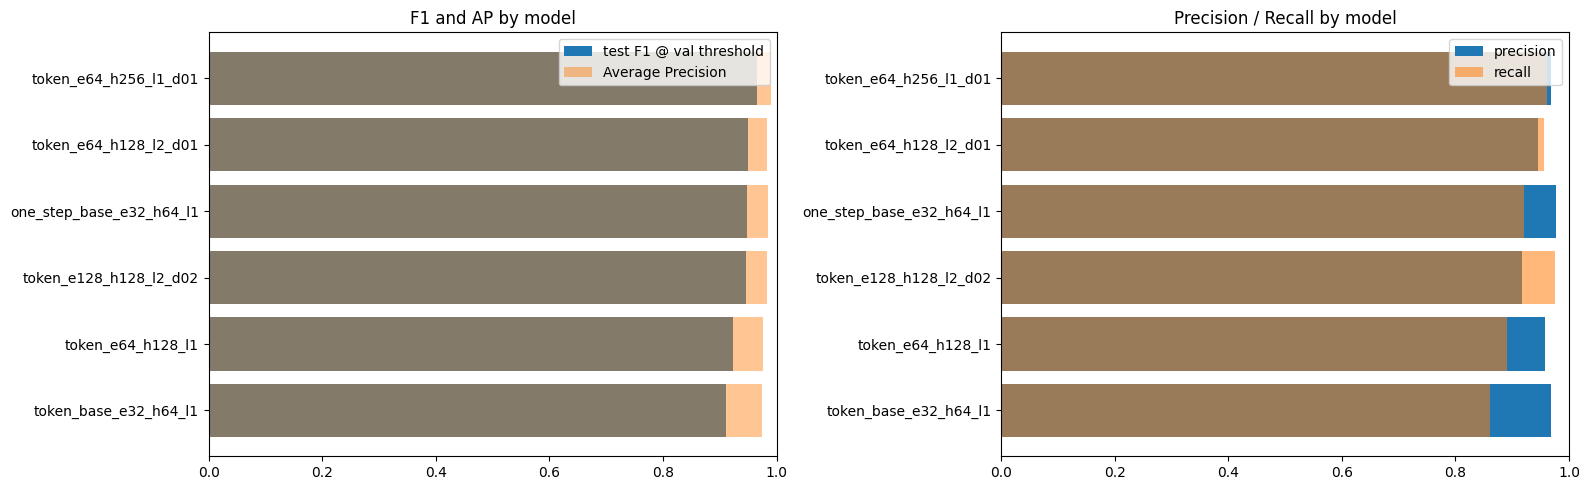

In [8]:
plot_df = results_df.sort_values("test_f1", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(plot_df["model"], plot_df["test_f1"], label="test F1 @ val threshold")
axes[0].barh(plot_df["model"], plot_df["average_precision"], alpha=0.45, label="Average Precision")
axes[0].set_xlim(0, 1.0)
axes[0].set_title("F1 and AP by model")
axes[0].legend()

axes[1].barh(plot_df["model"], plot_df["test_precision"], label="precision")
axes[1].barh(plot_df["model"], plot_df["test_recall"], alpha=0.55, label="recall")
axes[1].set_xlim(0, 1.0)
axes[1].set_title("Precision / Recall by model")
axes[1].legend()

plt.tight_layout()
plt.show()

### Сравнение стратегий скоринга для лучшей many-to-many модели

Для модели `token_e64_h256_l1_d01` сравниваются `topk_all`, `topk_last`, `topk_last3`, `nll_mean`, `nll_p95`, `nll_max`. Для каждой стратегии threshold подбирается на validation и применяется к test.

In [11]:
BEST_TOKEN_PATH = CHECKPOINT_DIR / "experiments" / "lstm_token_e64_h256_l1_d01.pt"
best_token_model, best_token_config = load_token_model(BEST_TOKEN_PATH, EVAL_DEVICE)


def token_topk_miss_matrix(model, x, y, device, top_k=3, batch_size=2048):
    rows = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            xb = torch.tensor(x[start : start + batch_size], dtype=torch.long, device=device)
            yb = torch.tensor(y[start : start + batch_size], dtype=torch.long, device=device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=-1)
            k = min(top_k, probs.shape[-1])
            topk = torch.topk(probs, k=k, dim=-1).indices
            correct = (topk == yb.unsqueeze(-1)).any(dim=-1)
            rows.append((~correct).cpu().numpy().astype(np.float32))
    return np.concatenate(rows, axis=0)


def token_nll_matrix(model, x, y, device, batch_size=2048):
    rows = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            xb = torch.tensor(x[start : start + batch_size], dtype=torch.long, device=device)
            yb = torch.tensor(y[start : start + batch_size], dtype=torch.long, device=device)
            logits = model(xb)
            log_probs = torch.log_softmax(logits, dim=-1)
            nll = -log_probs.gather(dim=-1, index=yb.unsqueeze(-1)).squeeze(-1)
            rows.append(nll.cpu().numpy())
    return np.concatenate(rows, axis=0)


def block_score_map_from_matrix(matrix, block_ids, agg="mean", positions="all"):
    if positions == "last":
        matrix = matrix[:, -1:]
    elif isinstance(positions, int):
        matrix = matrix[:, -positions:]
    elif positions != "all":
        raise ValueError(positions)

    block_to_values = {}
    for bid, row in zip(block_ids.astype(str), matrix):
        block_to_values.setdefault(str(bid), []).append(np.asarray(row, dtype=float))

    result = {}
    for bid, rows in block_to_values.items():
        values = np.concatenate(rows)
        if agg == "mean":
            result[bid] = float(values.mean())
        elif agg == "p95":
            result[bid] = float(np.quantile(values, 0.95))
        elif agg == "max":
            result[bid] = float(values.max())
        else:
            raise ValueError(agg)
    return result

best_val_miss = token_topk_miss_matrix(best_token_model, token["x_val"], token["y_val"], EVAL_DEVICE, top_k=3)
best_test_miss = token_topk_miss_matrix(best_token_model, token["x_test"], token["y_test"], EVAL_DEVICE, top_k=3)
best_val_nll = token_nll_matrix(best_token_model, token["x_val"], token["y_val"], EVAL_DEVICE)
best_test_nll = token_nll_matrix(best_token_model, token["x_test"], token["y_test"], EVAL_DEVICE)

best_token_val_labels = label_map(token["val_block_ids"], token["val_labels"])
best_token_test_labels = label_map(token["test_block_ids"], token["test_labels"])

In [12]:
score_specs = [
    ("topk_all", best_val_miss, best_test_miss, "mean", "all"),
    ("topk_last", best_val_miss, best_test_miss, "mean", "last"),
    ("topk_last3", best_val_miss, best_test_miss, "mean", 3),
    ("nll_mean", best_val_nll, best_test_nll, "mean", "all"),
    ("nll_p95", best_val_nll, best_test_nll, "p95", "all"),
    ("nll_max", best_val_nll, best_test_nll, "max", "all"),
]

best_model_scoring_rows = []
for score_name, val_matrix, test_matrix, agg, positions in score_specs:
    val_score_map = block_score_map_from_matrix(val_matrix, token["val_block_ids"], agg=agg, positions=positions)
    test_score_map = block_score_map_from_matrix(test_matrix, token["test_block_ids"], agg=agg, positions=positions)
    val_thr, val_metrics = best_threshold_by_f1(val_score_map, best_token_val_labels)
    test_metrics = metrics_at_threshold(test_score_map, best_token_test_labels, val_thr)
    test_best_thr, test_best_metrics = best_threshold_by_f1(test_score_map, best_token_test_labels)
    y_true, y_score = arrays_from_score_map(test_score_map, best_token_test_labels)
    ap = average_precision_score(y_true, y_score)
    best_model_scoring_rows.append(
        {
            "score": score_name,
            "val_threshold": val_thr,
            "val_f1": val_metrics["f1"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
            "test_fpr": test_metrics["fpr"],
            "average_precision": ap,
            "test_best_thr": test_best_thr,
            "test_best_f1": test_best_metrics["f1"],
        }
    )

best_model_scoring_df = pd.DataFrame(best_model_scoring_rows).sort_values("test_f1", ascending=False)
display(best_model_scoring_df.style.format({
    "val_threshold": "{:.4f}",
    "val_f1": "{:.3f}",
    "test_precision": "{:.3f}",
    "test_recall": "{:.3f}",
    "test_f1": "{:.3f}",
    "test_fpr": "{:.4f}",
    "average_precision": "{:.3f}",
    "test_best_thr": "{:.4f}",
    "test_best_f1": "{:.3f}",
}))

,score,val_threshold,val_f1,test_precision,test_recall,test_f1,test_fpr,average_precision,test_best_thr,test_best_f1
5,nll_max,8.2028,0.942,0.969,0.961,0.965,0.0041,0.991,7.9468,0.967
1,topk_last,0.0924,0.625,0.791,0.637,0.706,0.0226,0.713,0.0420,0.728
2,topk_last3,0.0588,0.560,0.659,0.752,0.702,0.0521,0.711,0.0588,0.702
3,nll_mean,0.9195,0.602,0.815,0.574,0.674,0.0174,0.771,0.7399,0.686
4,nll_p95,5.8594,0.605,0.942,0.448,0.607,0.0037,0.660,5.8168,0.606
0,topk_all,0.0941,0.515,0.843,0.402,0.544,0.0100,0.649,0.0515,0.568


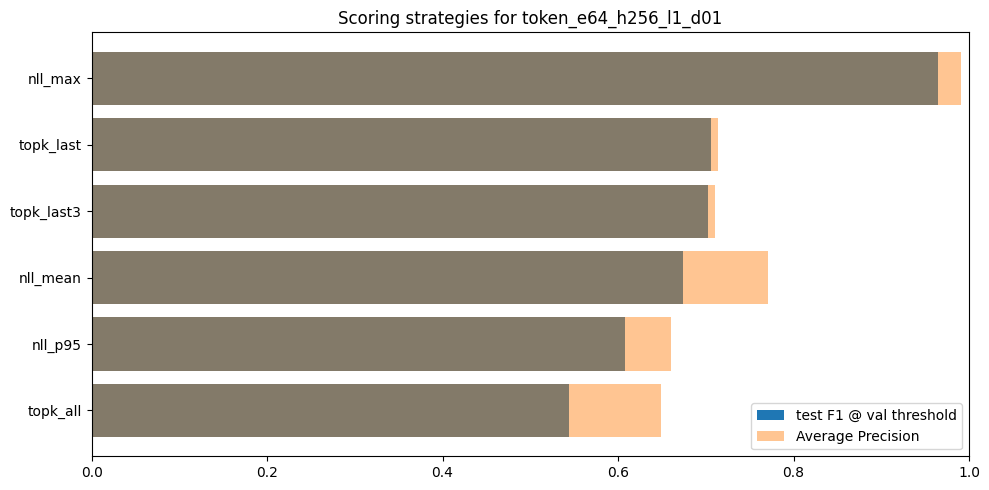

In [13]:
plot_df = best_model_scoring_df.sort_values("test_f1", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["score"], plot_df["test_f1"], label="test F1 @ val threshold")
plt.barh(plot_df["score"], plot_df["average_precision"], alpha=0.45, label="Average Precision")
plt.xlim(0, 1.0)
plt.title("Scoring strategies for token_e64_h256_l1_d01")
plt.legend()
plt.tight_layout()
plt.show()

Вывод: `nll_max` остаётся лучшей или одной из лучших стратегий на самой сильной many-to-many архитектуре. Т.о. итоговый результат связан не только с увеличением числа параметров, но и с устойчивым преимуществом NLL-based scoring над `top-k miss`.

### Выводы

Все модели сравнивались в одинаковых условиях: использовалась стратегия `nll_max`, порог подбирался на validation по максимуму F1, а итоговые метрики считались на test.

При старом top-k scoring качество many-to-many модели оказалось ниже one-step baseline. Это связано с тем,
что top-k miss является грубой бинарной метрикой и плохо использует вероятностный выход модели. Кроме того,
many-to-many objective распределяет loss по всем позициям окна, из-за чего сигнал редких аномальных переходов
при top-k агрегации размывается. Поэтому для many-to-many модели более подходящим оказался NLL-based scoring,
который учитывает степень неожиданности правильного next-token.


Лучший результат показала many-to-many LSTM `token_e64_h256_l1_d01`:

- `precision` = 0.969
- `recall` = 0.961
- `f1` = 0.965
- `fpr` = 0.0041
- `average precision` = 0.991

По сравнению с one-step baseline `one_step_base_e32_h64_l1`:

- `f1` вырос с 0.948 до 0.965 (`+0.017`)
- `recall` вырос с 0.921 до 0.961 (`+0.040`)
- `average precision` вырос с 0.986 до 0.991 (`+0.005`)
- `fpr` вырос с 0.0030 до 0.0041 (`+0.0011`)

Интерпретация: увеличение емкости many-to-many LSTM улучшило результат относительно базовой many-to-many модели и немного превзошло one-step baseline по F1 и recall. Лучшей конфигурацией стала модель с `embedding_dim=64`, `hidden_size=256`, `num_layers=1`, `dropout=0.1`.

Вывод: итоговое улучшение связано не только с переходом к many-to-many next-token objective, а с комбинацией `nll_max` scoring и более емкой LSTM-архитектуры. При этом рост FPR остается небольшим, поэтому улучшение recall не достигается ценой большого числа ложных срабатываний.